# CBAM y cabeza de detección implementados

Attention not only tells where to focus, it also improves the representation of interests. Our goal is to increase representation
power by using attention mechanism: focusing on important features and suppressing unnecessary ones.
we adopt our module to emphasize meaningful features along those two
principal dimensions: channel and spatial axes. To achieve this, we sequentially
apply channel and spatial attention modules, so that each of the branches can learn ‘what’ and ‘where’ to attend in the channel and spatial axes respectively. As a result, our module efficiently helps the information flow within the network by learning which information to emphasize or suppress.

CBAM: Convolutional Block Attention Module Sanghyun Woo, Jongchan Park, Joon-Young Lee and In So Kweon
https://arxiv.org/pdf/1807.06521

CBAM also gives weights to every single pixel in the spatial dimension of the image 
 CBAM consists of CAM and SAM. These two sub-blocks are responsible for creating attention weights, which will then be applied to the original tensor by multiplication. The output tensor of this block (the one referred to as Refined Features) has the exact same dimension as the input (Input Feature), meaning that we can easily plug CBAM to any backbone model without needing to worry about altering the tensor shapes.
 https://towardsdatascience.com/cbam-paper-walkthrough-the-double-attention-mechanism/

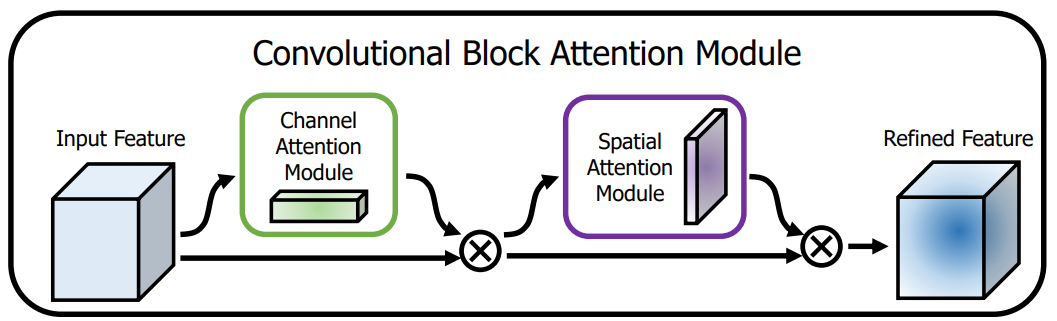

In [1]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle

SEED = 42
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
NAMES = ["base", "plus"]
RESULTADOS_CBAM = {n: {} for n in NAMES}
print("torch", torch.__version__, "| dispositivo:", DEVICE)

torch 2.14.1+cpu | dispositivo: cpu


In [2]:
SEED = 42
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
NAMES = ["base", "plus"]
RESULTADOS = {n: {} for n in NAMES}   # se llena en las pruebas y se resume al final
print("torch", torch.__version__, "| dispositivo:", DEVICE)

torch 2.14.1+cpu | dispositivo: cpu


In [3]:
class FundidoraPC(nn.Module):
    """4 bloques Conv3x3 -> BatchNorm -> ReLU -> MaxPool2x2 (version base)."""

    def __init__(self, in_channels=3):
        super().__init__()
        self.conv1 = nn.Conv2d(in_channels, 32, kernel_size=3, padding=1)
        self.bn1 = nn.BatchNorm2d(32)
        self.pool1 = nn.MaxPool2d(kernel_size=2)

        self.conv2 = nn.Conv2d(32, 64, kernel_size=3, padding=1)
        self.bn2 = nn.BatchNorm2d(64)
        self.pool2 = nn.MaxPool2d(kernel_size=2)

        self.conv3 = nn.Conv2d(64, 128, kernel_size=3, padding=1)
        self.bn3 = nn.BatchNorm2d(128)
        self.pool3 = nn.MaxPool2d(kernel_size=2)

        self.conv4 = nn.Conv2d(128, 256, kernel_size=3, padding=1)
        self.bn4 = nn.BatchNorm2d(256)
        self.pool4 = nn.MaxPool2d(kernel_size=2)

        self.global_pool = nn.AdaptiveAvgPool2d(output_size=1)
        self.out_features = 256

    def _encode(self, x):
        x = self.pool1(torch.relu(self.bn1(self.conv1(x))))
        x = self.pool2(torch.relu(self.bn2(self.conv2(x))))
        x = self.pool3(torch.relu(self.bn3(self.conv3(x))))
        # Solo 4 MaxPool en total: no agregar pooling extra.
        return self.pool4(torch.relu(self.bn4(self.conv4(x))))

    def forward(self, x):
        feature_map = self._encode(x)                                # [B, 256, H/16, W/16]
        pooled = self.global_pool(feature_map).flatten(start_dim=1)  # [B, 256]
        return pooled, feature_map


In [4]:
class FundidoraPCPlus(FundidoraPC):
    """Base + bloque de contexto a stride 16 (convs dilatadas, residual)."""
    def __init__(self, in_channels=3, dilations=(2, 4)):
        super().__init__(in_channels)
        self.dilations = tuple(dilations)
        layers = []
        for d in self.dilations:
            layers += [nn.Conv2d(256, 256, kernel_size=3, padding=d, dilation=d, bias=False),
                       nn.BatchNorm2d(256), nn.ReLU(inplace=True)]
        self.context = nn.Sequential(*layers)

    def _encode(self, x):
        feature_map = super()._encode(x)
        return feature_map + self.context(feature_map)


def build_backbone(name="base", in_channels=1):
    if name == "base":
        return FundidoraPC(in_channels=in_channels)
    if name == "plus":
        return FundidoraPCPlus(in_channels=in_channels)
    raise ValueError(f"backbone desconocido: {name!r}")


BASE_LAYERS = [(3, 1, 1), (2, 2, 1)] * 4          # (kernel, stride, dilation)
PLUS_LAYERS = BASE_LAYERS + [(3, 1, 2), (3, 1, 4)]
LAYERS = {"base": BASE_LAYERS, "plus": PLUS_LAYERS}

def theoretical_receptive_field(layers):
    r, j = 1, 1
    for k, s, d in layers:
        r += (k - 1) * d * j
        j *= s
    return r, j

def count_parameters(model):
    return sum(p.numel() for p in model.parameters())


def make_models(train=False):
    out = {}
    for n in NAMES:
        torch.manual_seed(SEED)
        m = build_backbone(n, in_channels=1).to(DEVICE)
        out[n] = m.train() if train else m.eval()
    return out

MODELS = make_models()
for n, m in MODELS.items():
    RESULTADOS[n]["parametros"] = count_parameters(m)
    RESULTADOS[n]["rf_teorico"] = theoretical_receptive_field(LAYERS[n])[0]
    print(f"{n:5s} parametros = {count_parameters(m):>9,} | RF teorico = {RESULTADOS[n]['rf_teorico']} px")

base  parametros =   388,800 | RF teorico = 46 px
plus  parametros = 1,569,472 | RF teorico = 238 px


In [5]:
class ChannelAttention(nn.Module):
    def __init__(self, channels, reduction=16):
        super().__init__()
        self.avg_pool = nn.AdaptiveAvgPool2d(1)
        self.max_pool = nn.AdaptiveMaxPool2d(1)
        hidden = max(channels // reduction, 8)
        self.mlp = nn.Sequential(
            nn.Conv2d(channels, hidden, kernel_size=1, bias=False),
            nn.ReLU(inplace=True),
            nn.Conv2d(hidden, channels, kernel_size=1, bias=False),
        )
        self.sigmoid = nn.Sigmoid()

    def forward(self, x):
        avg_out = self.mlp(self.avg_pool(x))
        max_out = self.mlp(self.max_pool(x))
        return self.sigmoid(avg_out + max_out)  # [B, C, 1, 1]


class SpatialAttention(nn.Module):
    def __init__(self, kernel_size=7):
        super().__init__()
        self.conv = nn.Conv2d(2, 1, kernel_size=kernel_size, padding=kernel_size // 2, bias=False)
        self.sigmoid = nn.Sigmoid()

    def forward(self, x):
        avg_out = x.mean(dim=1, keepdim=True)
        max_out, _ = x.max(dim=1, keepdim=True)
        concat = torch.cat([avg_out, max_out], dim=1)
        return self.sigmoid(self.conv(concat))  # [B, 1, H, W]


class CBAM(nn.Module):
    """Secuencial: primero atencion de canal, luego atencion espacial sobre el resultado."""
    def __init__(self, channels, reduction=16, spatial_kernel=7):
        super().__init__()
        self.channel_attention = ChannelAttention(channels, reduction)
        self.spatial_attention = SpatialAttention(spatial_kernel)

    def forward(self, x):
        channel_attn = self.channel_attention(x)
        x_channel = x * channel_attn
        spatial_attn = self.spatial_attention(x_channel)
        x_out = x_channel * spatial_attn
        return x_out, channel_attn, spatial_attn


def build_cbam_modules(channels=256, reduction=16, spatial_kernel=7):
    modules = {}
    for name in NAMES:
        torch.manual_seed(SEED)
        modules[name] = CBAM(channels, reduction, spatial_kernel).to(DEVICE)
    return modules

CBAM_MODULES = build_cbam_modules()
for name, cbam in CBAM_MODULES.items():
    n_params = count_parameters(cbam)
    RESULTADOS[name]["cbam_parametros"] = n_params
    print(f"[{name}] CBAM parametros = {n_params:,}")

[base] CBAM parametros = 8,290
[plus] CBAM parametros = 8,290


### Prueba 1: forma preservada

CBAM no debe alterar la forma del feature map, solo reponderarlo. Se verifica que
la salida tenga exactamente la misma forma que la entrada, y que los mapas de
atencion tengan las formas esperadas: [B, 256, 1, 1] para canal, [B, 1, 16, 16] para espacial.

In [6]:
for name, m in MODELS.items():
    cbam = CBAM_MODULES[name]
    with torch.no_grad():
        _, fmap = m(torch.rand(4, 1, 256, 256, device=DEVICE))
        out, ch_attn, sp_attn = cbam(fmap)

    assert out.shape == fmap.shape, (name, out.shape, fmap.shape)
    assert ch_attn.shape == (4, 256, 1, 1), ch_attn.shape
    assert sp_attn.shape == (4, 1, 16, 16), sp_attn.shape
    assert torch.isfinite(out).all()
    # Sigmoid garantiza rango (0,1) en ambos mapas de atencion
    assert ch_attn.min() >= 0 and ch_attn.max() <= 1
    assert sp_attn.min() >= 0 and sp_attn.max() <= 1

    print(f"[{name}] fmap {tuple(fmap.shape)} -> CBAM out {tuple(out.shape)} "
          f"| canal attn {tuple(ch_attn.shape)} rango=({ch_attn.min():.3f},{ch_attn.max():.3f}) "
          f"| espacial attn {tuple(sp_attn.shape)} rango=({sp_attn.min():.3f},{sp_attn.max():.3f})")

[base] fmap (4, 256, 16, 16) -> CBAM out (4, 256, 16, 16) | canal attn (4, 256, 1, 1) rango=(0.485,0.513) | espacial attn (4, 1, 16, 16) rango=(0.499,0.508)
[plus] fmap (4, 256, 16, 16) -> CBAM out (4, 256, 16, 16) | canal attn (4, 256, 1, 1) rango=(0.486,0.513) | espacial attn (4, 1, 16, 16) rango=(0.499,0.509)


### Prueba 2: gradientes no nulos, de punta a punta

Se verifica que el gradiente fluya correctamente a traves de todo el camino:
backbone -> CBAM -> perdida. Esto confirma que CBAM es entrenable y que no bloquea
la propagacion hacia las capas del backbone (ej. conv1).

In [7]:
for name in NAMES:
    torch.manual_seed(SEED)
    backbone = build_backbone(name, in_channels=1).to(DEVICE).train()
    cbam = CBAM(256).to(DEVICE).train()

    backbone.zero_grad()
    cbam.zero_grad()

    _, fmap = backbone(torch.rand(4, 1, 256, 256, device=DEVICE))
    out, ch_attn, sp_attn = cbam(fmap)
    out.mean().backward()

    # Gradientes del CBAM
    for n, p in cbam.named_parameters():
        assert p.grad is not None, f"CBAM sin gradiente: {n}"
        assert torch.isfinite(p.grad).all(), f"CBAM gradiente no finito: {n}"

    # Gradiente debe llegar hasta la primera capa del backbone (conv1)
    grad_conv1 = backbone.conv1.weight.grad
    assert grad_conv1 is not None, "el gradiente no llego hasta conv1 del backbone"
    assert torch.isfinite(grad_conv1).all()
    assert grad_conv1.norm().item() > 0

    print(f"[{name}] gradiente CBAM OK | norma grad conv1 (backbone) = {grad_conv1.norm().item():.3e}")

[base] gradiente CBAM OK | norma grad conv1 (backbone) = 1.218e-02
[plus] gradiente CBAM OK | norma grad conv1 (backbone) = 3.268e-02


### Prueba 3: comparacion de forward con y sin CBAM

Se compara el feature map antes y despues de CBAM, usando el mismo batch de entrada.
Si CBAM funciona, se debe observar reponderacion real: algunos canales se atenuan
mas que otros (atencion de canal no uniforme), y el mapa espacial debe concentrarse
en regiones especificas (no ser plano/uniforme).

[base] diferencia relativa fmap vs fmap_cbam = 74.77% | std atencion de canal = 0.0051
[plus] diferencia relativa fmap vs fmap_cbam = 74.77% | std atencion de canal = 0.0051


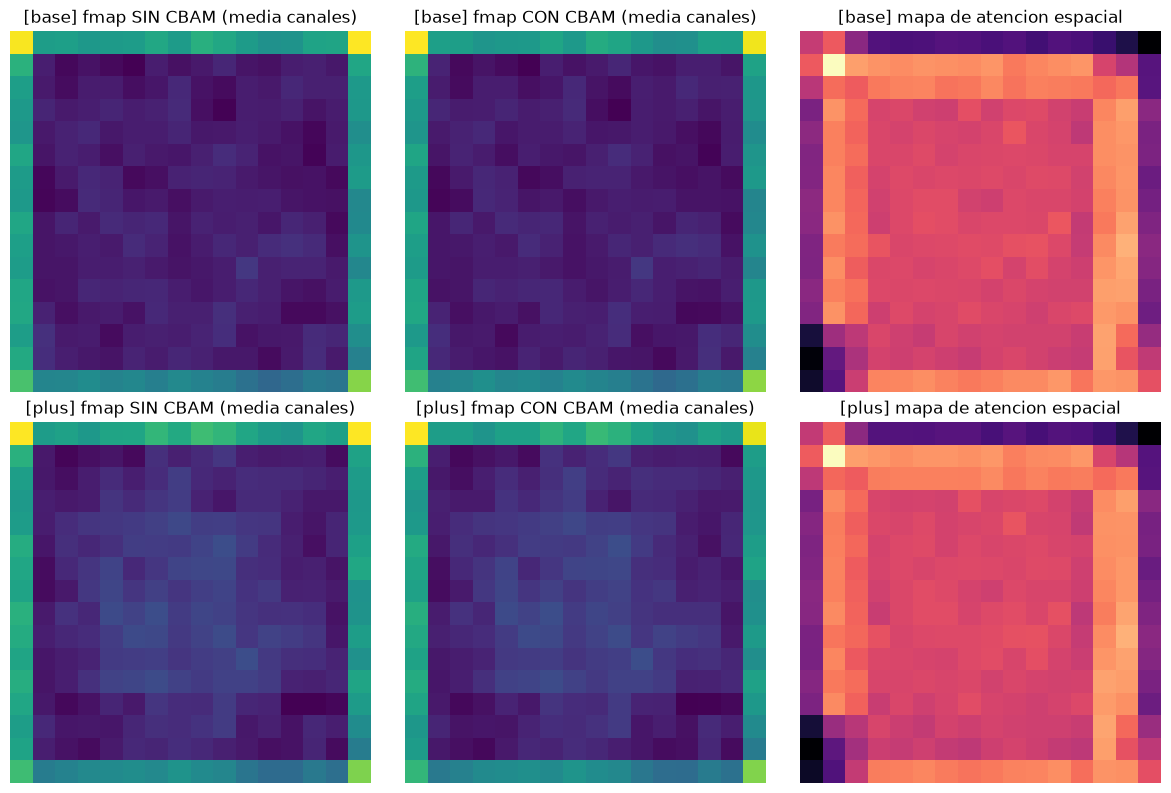

In [8]:
x_test = torch.rand(4, 1, 256, 256, device=DEVICE)

fig, axes = plt.subplots(len(NAMES), 3, figsize=(12, 4 * len(NAMES)))
if len(NAMES) == 1:
    axes = axes[None, :]

for row, name in enumerate(NAMES):
    m = MODELS[name]
    cbam = CBAM_MODULES[name]

    with torch.no_grad():
        _, fmap = m(x_test)
        fmap_cbam, ch_attn, sp_attn = cbam(fmap)

    # Diferencia relativa entre feature map original y con CBAM
    diff_relativa = ((fmap - fmap_cbam).abs().mean() / fmap.abs().mean()).item()
    # Dispersion de la atencion de canal: si es ~0, CBAM no esta discriminando canales
    ch_attn_std = ch_attn.std().item()

    assert diff_relativa > 0.01, f"[{name}] CBAM casi no cambia el feature map (sospechoso)"
    assert ch_attn_std > 0.001, f"[{name}] atencion de canal demasiado uniforme (sospechoso)"

    print(f"[{name}] diferencia relativa fmap vs fmap_cbam = {diff_relativa:.2%} "
          f"| std atencion de canal = {ch_attn_std:.4f}")

    sin_cbam_vis = fmap.mean(dim=1)[0].cpu()
    con_cbam_vis = fmap_cbam.mean(dim=1)[0].cpu()
    sp_attn_vis = sp_attn[0, 0].cpu()

    axes[row, 0].imshow(sin_cbam_vis, cmap="viridis")
    axes[row, 0].set_title(f"[{name}] fmap SIN CBAM (media canales)")
    axes[row, 1].imshow(con_cbam_vis, cmap="viridis")
    axes[row, 1].set_title(f"[{name}] fmap CON CBAM (media canales)")
    axes[row, 2].imshow(sp_attn_vis, cmap="magma")
    axes[row, 2].set_title(f"[{name}] mapa de atencion espacial")
    for ax in axes[row]:
        ax.axis("off")

plt.tight_layout()
plt.show()

### Prueba 4: integracion antes de la cabeza de deteccion

Se conecta backbone -> CBAM -> cabeza, replicando la Prueba 7 del backbone pero
ahora con CBAM en medio. Se confirma que la forma de salida de la cabeza no cambia
(sigue siendo [B, 8, 16, 16]: 1 objectness + 4 caja + 3 clases), y que el gradiente
sigue fluyendo correctamente a traves de las tres piezas juntas.

In [9]:
head = nn.Conv2d(256, 1 + 4 + 3, kernel_size=1).to(DEVICE)

for name, m in MODELS.items():
    cbam = CBAM_MODULES[name]

    with torch.no_grad():
        _, fmap = m(torch.rand(4, 1, 256, 256, device=DEVICE))
        fmap_cbam, _, _ = cbam(fmap)
        salida = head(fmap_cbam)

    assert salida.shape == (4, 8, 16, 16), salida.shape
    print(f"[{name}] backbone -> CBAM -> cabeza: fmap {tuple(fmap.shape)} "
          f"-> salida {tuple(salida.shape)} OK")

# Gradiente de punta a punta: backbone -> CBAM -> cabeza
torch.manual_seed(SEED)
backbone = build_backbone("base", in_channels=1).to(DEVICE).train()
cbam = CBAM(256).to(DEVICE).train()
head_train = nn.Conv2d(256, 8, kernel_size=1).to(DEVICE)

backbone.zero_grad(); cbam.zero_grad(); head_train.zero_grad()

_, fmap = backbone(torch.rand(4, 1, 256, 256, device=DEVICE))
fmap_cbam, _, _ = cbam(fmap)
salida = head_train(fmap_cbam)
salida.mean().backward()

assert backbone.conv1.weight.grad is not None
assert torch.isfinite(backbone.conv1.weight.grad).all()
print("Gradiente de punta a punta (backbone -> CBAM -> cabeza) OK")

[base] backbone -> CBAM -> cabeza: fmap (4, 256, 16, 16) -> salida (4, 8, 16, 16) OK
[plus] backbone -> CBAM -> cabeza: fmap (4, 256, 16, 16) -> salida (4, 8, 16, 16) OK
Gradiente de punta a punta (backbone -> CBAM -> cabeza) OK


Prueba 5

Loss inicial: 0.6944 -> Loss final: 0.0001
Accuracy final sobre el batch de entrenamiento: 100.0%
std atencion de canal ANTES de entrenar:  0.0037
std atencion de canal DESPUES de entrenar: 0.4428
CBAM se vuelve discriminativo al entrenar: OK


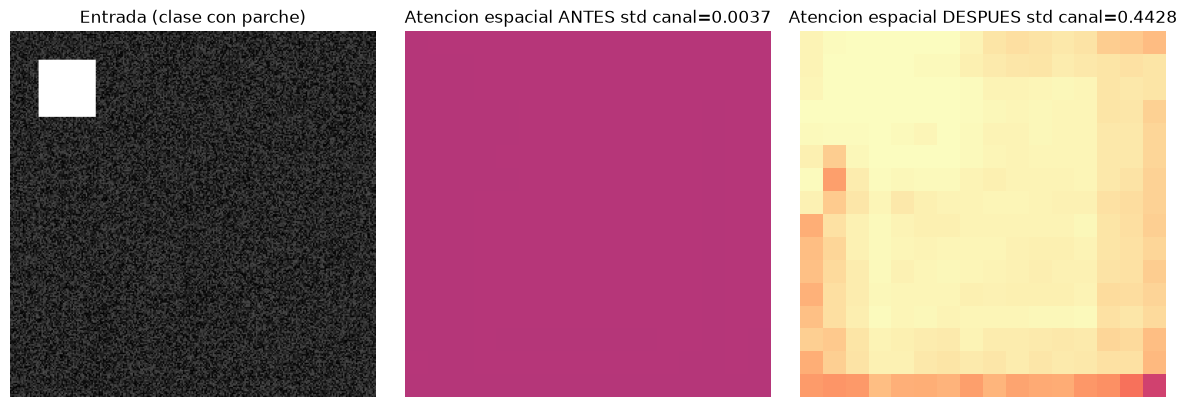

In [10]:
torch.manual_seed(SEED)
backbone_p5 = build_backbone("base", in_channels=1).to(DEVICE)
cbam_p5 = CBAM(256).to(DEVICE)
head_p5 = nn.Linear(256, 2).to(DEVICE)  # clasificacion binaria simple

# Batch sintetico: la mitad de las imagenes tiene un parche brillante en una
# esquina fija (clase 1), la otra mitad no (clase 0). Señal trivialmente
# separable si el modelo aprende a mirar esa zona.
torch.manual_seed(SEED)
batch_size = 16
x_synth = torch.rand(batch_size, 1, 256, 256, device=DEVICE) * 0.3
y_synth = torch.zeros(batch_size, dtype=torch.long, device=DEVICE)
for i in range(batch_size):
    if i % 2 == 0:
        x_synth[i, 0, 20:60, 20:60] = 1.0
        y_synth[i] = 1

# Atencion de canal y espacial ANTES de entrenar (referencia)
backbone_p5.eval(); cbam_p5.eval()
with torch.no_grad():
    _, fmap0 = backbone_p5(x_synth)
    _, ch_attn0, sp_attn0 = cbam_p5(fmap0)
std_canal_antes = ch_attn0.std().item()

params = list(backbone_p5.parameters()) + list(cbam_p5.parameters()) + list(head_p5.parameters())
optimizer = torch.optim.Adam(params, lr=1e-3)

backbone_p5.train(); cbam_p5.train(); head_p5.train()
losses = []
for step in range(150):
    optimizer.zero_grad()
    _, fmap = backbone_p5(x_synth)
    fmap_cbam, ch_attn, sp_attn = cbam_p5(fmap)
    pooled = fmap_cbam.mean(dim=(2, 3))
    logits = head_p5(pooled)
    loss = F.cross_entropy(logits, y_synth)
    loss.backward()
    optimizer.step()
    losses.append(loss.item())

backbone_p5.eval(); cbam_p5.eval()
with torch.no_grad():
    _, fmap_final = backbone_p5(x_synth)
    _, ch_attn_final, sp_attn_final = cbam_p5(fmap_final)
std_canal_despues = ch_attn_final.std().item()
accuracy_final = (logits.argmax(dim=1) == y_synth).float().mean().item()

print(f"Loss inicial: {losses[0]:.4f} -> Loss final: {losses[-1]:.4f}")
print(f"Accuracy final sobre el batch de entrenamiento: {accuracy_final:.1%}")
print(f"std atencion de canal ANTES de entrenar:  {std_canal_antes:.4f}")
print(f"std atencion de canal DESPUES de entrenar: {std_canal_despues:.4f}")

assert losses[-1] < losses[0] * 0.5, "el loss no bajo lo suficiente (revisar lr/pasos)"
assert accuracy_final > 0.9, "no se logro overfit sobre el batch pequeño"
assert std_canal_despues > std_canal_antes, "CBAM no se volvio mas discriminativo tras entrenar"
print("CBAM se vuelve discriminativo al entrenar: OK")

fig, axes = plt.subplots(1, 3, figsize=(12, 4))
axes[0].imshow(x_synth[0, 0].detach().cpu(), cmap="gray")
axes[0].set_title("Entrada (clase con parche)")
axes[1].imshow(sp_attn0[0, 0].cpu(), cmap="magma", vmin=0, vmax=1)
axes[1].set_title(f"Atencion espacial ANTES std canal={std_canal_antes:.4f}")
axes[2].imshow(sp_attn_final[0, 0].detach().cpu(), cmap="magma", vmin=0, vmax=1)
axes[2].set_title(f"Atencion espacial DESPUES std canal={std_canal_despues:.4f}")
for ax in axes:
    ax.axis("off")
plt.tight_layout()
plt.show()